In [91]:
# ==========================================
# BLOCO 1: IMPORTAÇÕES E CONFIGURAÇÃO
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display, SVG,Markdown
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
import io
from PIL import Image
from rdkit.Chem.Draw import rdMolDraw2D

pasta_arquivos = 'C:\TCC_ICM_USP/'
pasta_imagens = 'C:\TCC_ICM_USP/Imagens/'
# Configurações visuais para os gráficos do artigo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Bibliotecas de manipulação de dados importadas com sucesso!")

# Carregamento dos dados brutos
df_tox21_raw = pd.read_parquet(pasta_arquivos+'tox21_raw.parquet')
df_sider_raw = pd.read_parquet(pasta_arquivos+'sider_raw.parquet')

# Carregamento dos dados
df_tox_indiv = pd.read_csv(os.path.join(pasta_arquivos, 'tox21_metricas_vias_individuais.csv'))
df_sider_indiv = pd.read_csv(os.path.join(pasta_arquivos, 'sider_metricas_vias_individuais.csv'))
df_tox_multi = pd.read_csv(os.path.join(pasta_arquivos, 'tox21_relatorio_multirrotulo_final.csv'))
df_sider_multi = pd.read_csv(os.path.join(pasta_arquivos, 'sider_relatorio_multirrotulo_final.csv'))
df_tox_cohesive= pd.read_csv(os.path.join(pasta_arquivos, 'resultados_tox21_cohesive_br_vs_cc.csv'))
df_sider = pd.read_csv(os.path.join(pasta_arquivos, 'resultados_sider_cv_metricas.csv'))


Bibliotecas de manipulação de dados importadas com sucesso!


-> Imagem cortada salva em: C:\TCC_ICM_USP/Imagens/ccoc1ccc2nc(s(n)(=o)=o)sc2c1.png


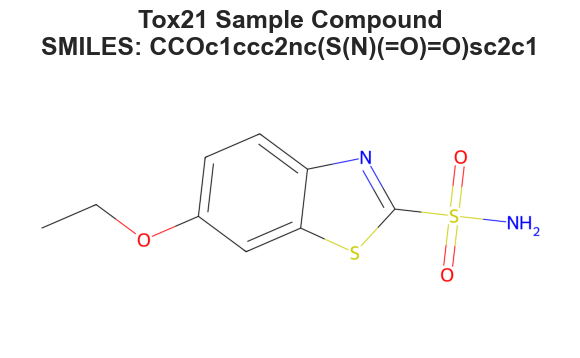

In [92]:
# ==========================================
# BLOCO 2: VISUALIZAÇÃO DE MOLÉCULAS (CROP VERTICAL)
# ==========================================

def plot_mol_from_smiles(smiles, nome="Molecula", salvar=False):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # 1. Gerar imagem base quadrada
        d2d = rdMolDraw2D.MolDraw2DCairo(1200, 1200)
        opts = d2d.drawOptions()
        opts.padding = 0.05
        
        copy_mol = Chem.Mol(mol)
        rdMolDraw2D.PrepareAndDrawMolecule(d2d, copy_mol)
        d2d.FinishDrawing()
        
        img_data = d2d.GetDrawingText()
        img = Image.open(io.BytesIO(img_data))
        
        # 2. Configurar figura RETANGULAR para reduzir sobra vertical
        plt.figure(figsize=(6, 3.5)) # Largura maior que altura
        plt.imshow(img)
        plt.axis('off')
        
        # --- AJUSTE FINO DE CORTE (CROP) ---
        # No imshow, a coordenada 0,0 é o topo esquerdo. 
        # Aumentar o limite inferior de 'y' corta a base. 
        # Diminuir o limite superior de 'y' corta o topo.
        plt.ylim(900, 300) # Exemplo: Foca na faixa central (0 a 600)
        
        # Título posicionado no novo topo
        plt.title(f"Tox21 Sample Compound\nSMILES: {smiles}", 
                  fontsize=18, 
                  fontweight='bold', 
                  pad=10)

        plt.subplots_adjust(left=0, right=1, top=0.8, bottom=0)
        
        if salvar:
            nome_arq = f"{nome.replace(' ', '_').lower()}.png"
            caminho_final = os.path.join(pasta_imagens, nome_arq)
            plt.savefig(caminho_final, dpi=300, bbox_inches='tight', pad_inches=0)
            print(f"-> Imagem cortada salva em: {caminho_final}")
        
        plt.show()
    else:
        print("SMILES inválido.")

# Execução
posicao = 0 
exemplo_smiles = df_tox21_raw['smiles'].iloc[posicao]
plot_mol_from_smiles(exemplo_smiles, nome=f"{df_tox21_raw['smiles'].iloc[posicao]}", salvar=True)

-> Fragmentos (Cairo) salvos em: C:\TCC_ICM_USP/Imagens/CCOc1ccc2nc(S(N)(=O)=O)sc2c1_fingerprints.png


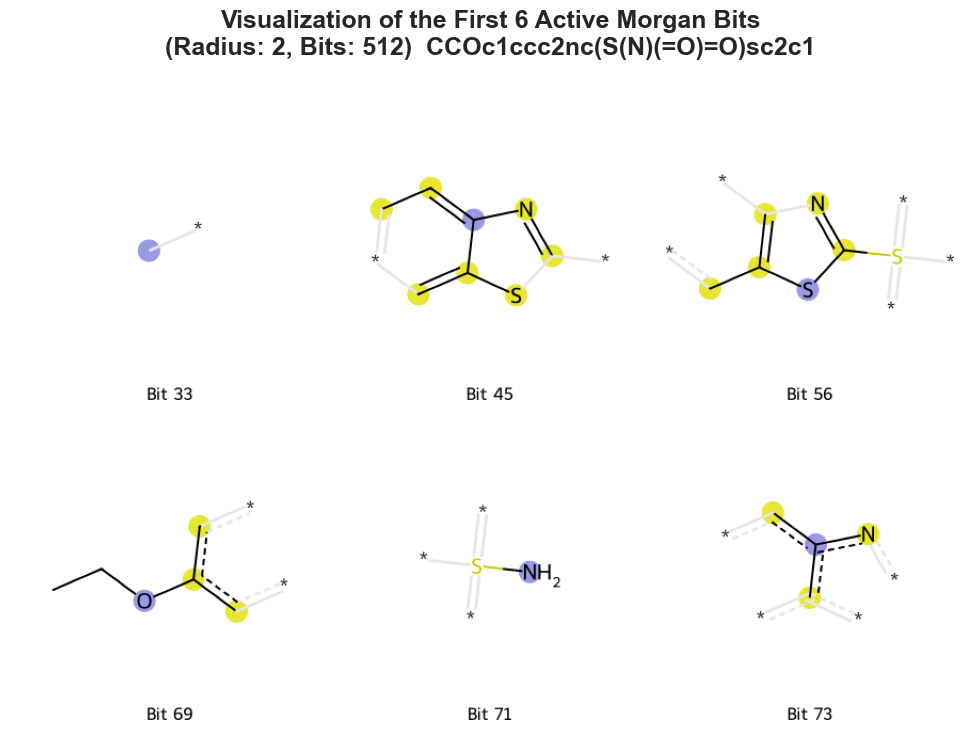

In [93]:
# ==========================================
# BLOCO 3: MORGAN FINGERPRINTS (REPRESENTAÇÃO VIA CAIRO)
# ==========================================
def visualizar_bits_morgan(smiles, n_bits=512, radius=2, nome="Molecula", salvar=False):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        print("SMILES inválido.")
        return

    # 1. Gerador e Captura de bitInfo
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()
    mfpgen.GetCountFingerprint(mol, additionalOutput=ao)
    bit_info = ao.GetBitInfoMap()

    # Seleção dos bits
    bits_para_exibir = list(bit_info.keys())[:6]
    if not bits_para_exibir:
        print("Nenhum bit encontrado.")
        return

    # 2. Preparar subestruturas para o Grid
    # Criamos uma lista de tuplas (mol, bit_id, bit_info) para o DrawMorganBits
    info_bits = [(mol, bit, bit_info) for bit in bits_para_exibir]
    
    # Gerar a imagem usando o backend Cairo do RDKit
    # molsPerRow=3 gera um grid 2x3 para 6 bits
    img = Draw.DrawMorganBits(
        info_bits, 
        molsPerRow=3, 
        subImgSize=(300, 300),
        legends=[f"Bit {b}" for b in bits_para_exibir]
    )

    # 3. Renderização Final via Matplotlib (Controle de Título e Tamanho)
    # Ajustamos o figsize proporcional ao grid (3 colunas, 2 linhas)
    plt.figure(figsize=(12, 8)) 
    plt.imshow(img)
    plt.axis('off')
    
    # Título acadêmico
    plt.title(f"Visualization of the First 6 Active Morgan Bits\n(Radius: {radius}, Bits: {n_bits})  {smiles}", 
              fontsize=18, fontweight='bold', pad=30)

    # Remove vácuos desnecessários nas bordas
    plt.subplots_adjust(left=0.05, right=0.95, top=0.85, bottom=0.05)

    if salvar:
        nome_arq = f"{smiles}_fingerprints.png"
        caminho_final = os.path.join(pasta_imagens, nome_arq)
        # O bbox_inches='tight' garante que o título apareça no arquivo salvo
        plt.savefig(caminho_final, dpi=300, bbox_inches='tight', pad_inches=0.1)
        print(f"-> Fragmentos (Cairo) salvos em: {caminho_final}")

    plt.show()

# --- Execução ---
visualizar_bits_morgan(
    df_tox21_raw['smiles'].iloc[0], 
    nome="Exemplo Tox21 (Pos 0)", 
    salvar=True
)

-> Distribuição SIDER salva em: C:\TCC_ICM_USP/Imagens/label_distribution_and_class_imbalance_per_system_organ_classes_(sider).png


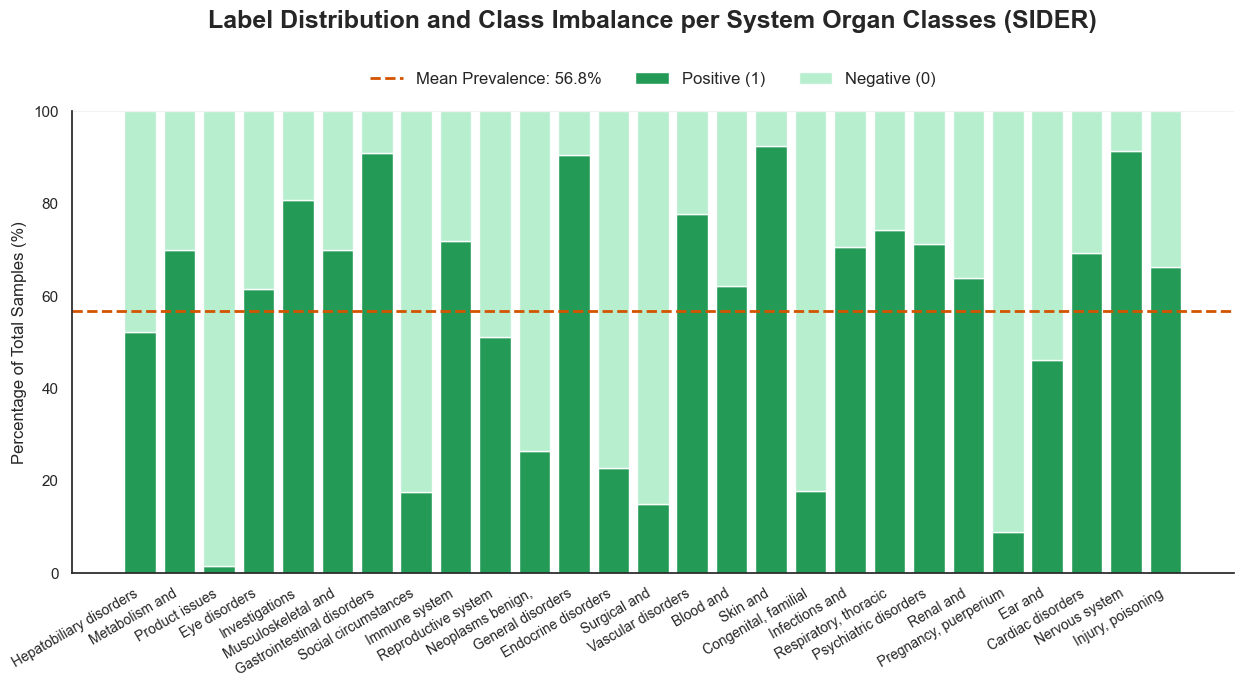

In [94]:
# ==========================================
# BLOCK 4: CLASS DISTRIBUTION & AVAILABILITY (SIDER) - ROTULOS REDUZIDOS
# ==========================================

def plot_sider_distribution_v2(df, title="Label Distribution and Class Imbalance per System Organ Classes (SIDER)"):
    plt.figure(figsize=(15, 6)) # Aumentei um pouco a altura para acomodar as labels
    sns.set_style("white") 

    # 1. Preparação dos dados
    labels = df.drop(columns=['smiles'])
    total_rows = len(df)

    # Calculando as porcentagens
    positives = (labels == 1).sum() / total_rows * 100
    negatives = (labels == 0).sum() / total_rows * 100
    availability = labels.notnull().mean() * 100

    # Ordenando pela disponibilidade
    indices = availability.sort_values(ascending=False).index
    
    # --- AJUSTE DOS RÓTULOS (LIMITE DE 2 PALAVRAS) ---
    # Transforma 'Hepatobiliary disorders' em 'Hepatobiliary disorders' 
    # e 'Respiratory, thoracic and mediastinal disorders' em 'Respiratory, thoracic'
    short_indices = [" ".join(idx.split()[:2]) for idx in indices]
    
    pos_sorted = positives.reindex(indices)
    neg_sorted = negatives.reindex(indices)

    # 2. Definição de Cores
    color_pos = "#239B56" # Verde Floresta
    color_neg = '#ABEBC6' # Verde Menta Claro
    color_mean = '#D35400' # Abóbora

    # 3. Plotagem usando os novos nomes curtos no eixo X
    plt.bar(short_indices, pos_sorted, color=color_pos, label='Positive (1)', edgecolor=None)
    plt.bar(short_indices, neg_sorted, bottom=pos_sorted, color=color_neg, label='Negative (0)', edgecolor=None, alpha=0.85)

    # 4. Linha Tracejada da Média
    avg_pos = pos_sorted.mean()
    plt.axhline(avg_pos, color=color_mean, linestyle='--', linewidth=2,
                label=f'Mean Prevalence: {avg_pos:.1f}%')

    # --- ESTILIZAÇÃO MINIMALISTA ---
    sns.despine()

    # Rotação menor (30) costuma ser suficiente para nomes de 2 palavras
    plt.xticks(rotation=30, ha='right', fontsize=10)
    plt.ylabel("Percentage of Total Samples (%)", fontsize=12)
    plt.xlabel("", fontsize=1)

    plt.title(title, fontsize=18, fontweight='bold', pad=60)
    plt.ylim(0, 100)
    plt.axhline(100, color='black', linestyle='-', alpha=0.05)

    # 5. Legenda Horizontal no Topo
    plt.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=3,
        frameon=False,
        fontsize=12 # Reduzi de 15 para 12 para evitar conflito visual
    )

    # --- SALVAMENTO CORRIGIDO ---
    nome_arquivo = f"{title.replace(' ', '_').lower()}.png"
    caminho_final = os.path.join(pasta_imagens, nome_arquivo)
    
    # Salvar antes de mostrar, usando bbox_inches='tight' para não cortar as labels curtas
    plt.savefig(caminho_final, dpi=300, bbox_inches='tight')
    print(f"-> Distribuição SIDER salva em: {caminho_final}")
    
    plt.show()

# Executando
plot_sider_distribution_v2(df_sider_raw)

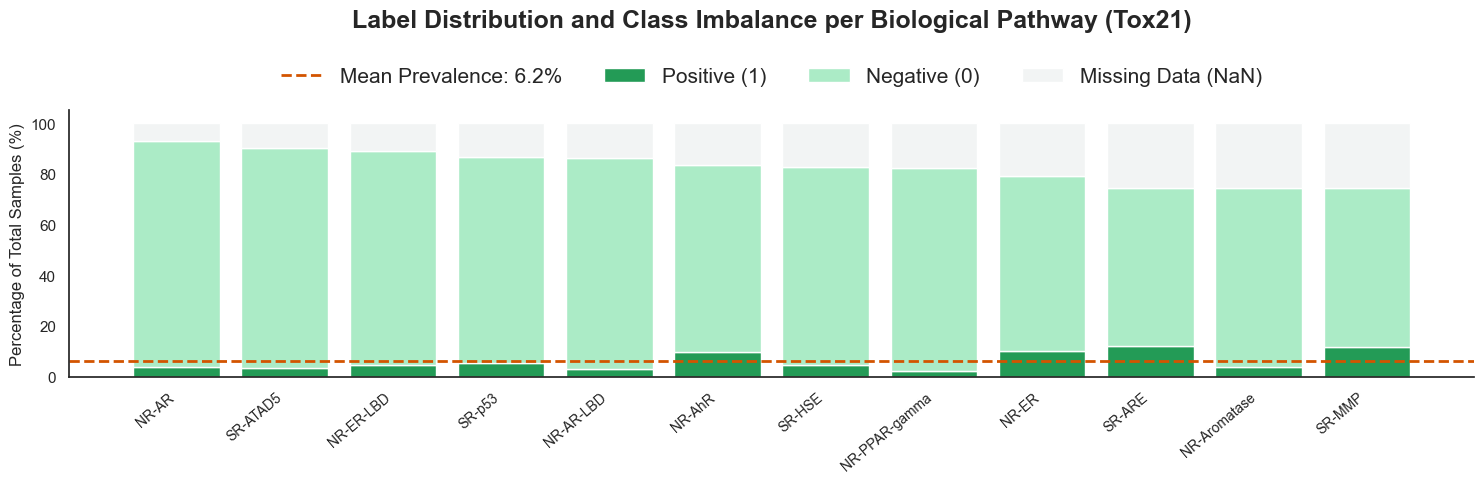

In [95]:
# ==========================================
# BLOCK 5: DISTRIBUTION & SPARSITY (TOX21) - MINIMALISTA
# ==========================================

def plot_tox21_distribution(df, title="Label Distribution and Class Imbalance per Biological Pathway (Tox21)"):
    plt.figure(figsize=(15, 5))
    sns.set_style("white")

    # 1. Preparação dos dados
    labels = df.filter(regex='NR-|SR-')
    total_rows = len(df)

    # Calculando as porcentagens
    positives = (labels == 1).sum() / total_rows * 100
    negatives = (labels == 0).sum() / total_rows * 100
    nans = labels.isna().sum() / total_rows * 100

    # Ordenando pela disponibilidade de dados (menos NaNs primeiro)
    availability = 100 - nans
    indices = availability.sort_values(ascending=False).index

    pos_sorted = positives.reindex(indices)
    neg_sorted = negatives.reindex(indices)
    nan_sorted = nans.reindex(indices)

    # 2. Definição de Cores
    color_pos = "#239B56" # Verde Floresta (Positivos)
    color_neg = '#ABEBC6' # Verde Menta Claro (Negativos)
    color_nan = '#F2F4F4' # Cinza Perolado (Quase branco, para NaNs)
    color_mean = '#D35400' # Abóbora (Média)

    # 3. Plotagem das Barras Empilhadas (Sem bordas)
    plt.bar(indices, pos_sorted, color=color_pos, label='Positive (1)', edgecolor=None)
    plt.bar(indices, neg_sorted, bottom=pos_sorted, color=color_neg, label='Negative (0)', edgecolor=None)
    plt.bar(indices, nan_sorted, bottom=pos_sorted + neg_sorted, color=color_nan, label='Missing Data (NaN)', edgecolor=None)

    # 4. Linha da Média de Positivos
    avg_pos = pos_sorted.mean()
    plt.axhline(avg_pos, color=color_mean, linestyle='--', linewidth=2,
                label=f'Mean Prevalence: {avg_pos:.1f}%')

    # --- ESTILIZAÇÃO MINIMALISTA ---

    sns.despine() # Remove bordas superior e direita

    plt.xticks(rotation=40, ha='right', fontsize=10)
    plt.ylabel("Percentage of Total Samples (%)", fontsize=12)
    plt.xlabel("", fontsize=1, labelpad=10)

    # Título com pad alto para a legenda horizontal
    plt.title(title, fontsize=18, fontweight='bold', pad=60)

    plt.ylim(0, 105) # Limite em 100% + respiro

    # 5. Legenda Horizontal no Topo
    plt.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        ncol=4, # Agora são 4 itens (Pos, Neg, NaN, Média)
        frameon=False,
        fontsize=15
    )

    # --- SALVAMENTO ---
    nome_arquivo = f"{title.replace(' ', '_').lower()}.png"
    caminho_final = os.path.join(pasta_imagens, nome_arquivo)

    # bbox_inches='tight' garante que o título e a legenda não sejam cortados
    plt.savefig(caminho_final, dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

# Executando
plot_tox21_distribution(df_tox21_raw)

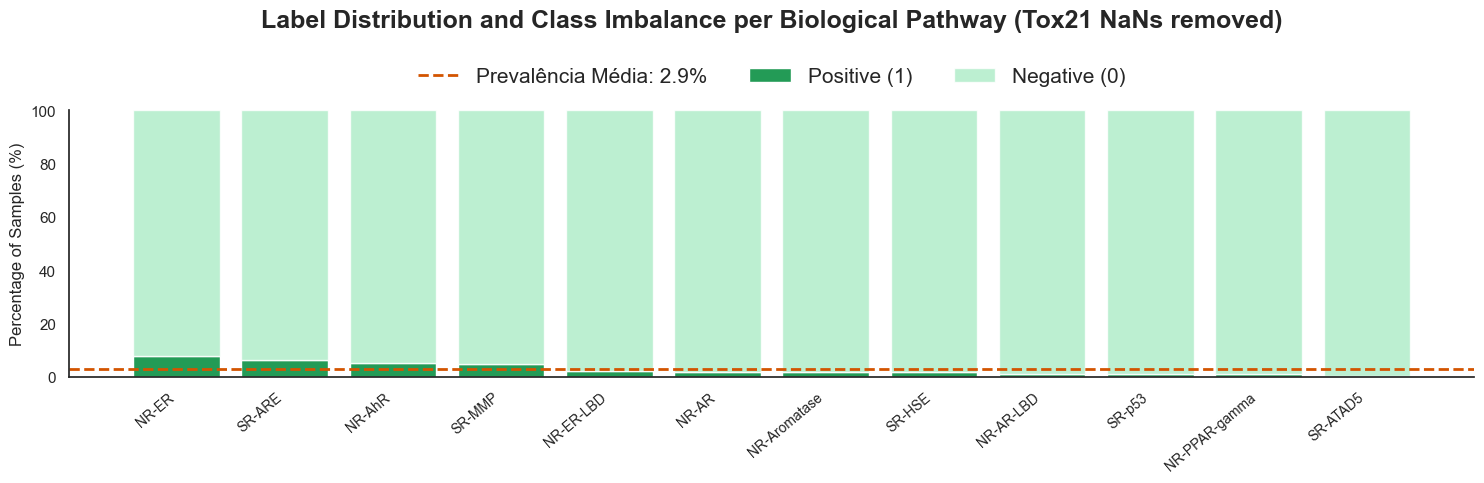

In [96]:
# ==========================================
# BLOCK 6: CLASS DISTRIBUTION (TOX21) - MINIMALISTA FINAL
# ==========================================

def plot_tox21_cohesive_distribution(df, title="Label Distribution and Class Imbalance per Biological Pathway (Tox21 NaNs removed)"):
    plt.figure(figsize=(15, 5))
    sns.set_style("white") # Fundo limpo sem grades pesadas

    # 1. Preparação dos dados
    labels = df.filter(regex='NR-|SR-')
    total_rows = len(df)

    positives = (labels == 1).sum() / total_rows * 100
    negatives = (labels == 0).sum() / total_rows * 100

    indices = positives.sort_values(ascending=False).index
    pos_sorted = positives.reindex(indices)
    neg_sorted = negatives.reindex(indices)

    # 2. Definição de Cores (Padrão Acadêmico Verde)
    color_pos = "#239B56" # Verde Floresta (Positivos)
    color_neg = '#ABEBC6' # Verde Menta Claro (Negativos)
    color_mean = '#D35400' # Abóbora (Média - padrão TabPFN)

    # 3. Plotagem das Barras Empilhadas
    plt.bar(indices, pos_sorted, color=color_pos, label='Positive (1)', edgecolor=None)
    plt.bar(indices, neg_sorted, bottom=pos_sorted, color=color_neg, label='Negative (0)', edgecolor=None, alpha=0.8)

    # 4. Linha da Média de Positivos
    avg_pos = pos_sorted.mean()
    plt.axhline(avg_pos, color=color_mean, linestyle='--', linewidth=2,
                label=f'Prevalência Média: {avg_pos:.1f}%')

    # --- ESTILIZAÇÃO MINIMALISTA ---

    sns.despine() # Remove bordas superior e direita

    plt.xticks(rotation=40, ha='right', fontsize=10)
    plt.ylabel("Percentage of Samples (%)", fontsize=12)
    plt.xlabel("", fontsize=1, labelpad=10)

    # Título com PAD maior para acomodar a legenda horizontal embaixo dele
    plt.title(title, fontsize=18, fontweight='bold', pad=60)

    plt.ylim(0, 100)

    # 5. Legenda Horizontal no Topo
    plt.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02), # Centralizado (0.5) logo acima do eixo (1.02)
        ncol=3,
        frameon=False,
        fontsize=15
    )

    
    # --- SALVAMENTO ---
    nome_arquivo = f"{title.replace(' ', '_').lower()}.png"
    caminho_final = os.path.join(pasta_imagens, nome_arquivo)

    # bbox_inches='tight' garante que o título e a legenda não sejam cortados
    plt.savefig(caminho_final, dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

# Execução
df_tox21_coeso = df_tox21_raw.dropna(subset=df_tox21_raw.filter(regex='NR-|SR-').columns)
plot_tox21_cohesive_distribution(df_tox21_coeso)

-> Gráfico corrigido com média global salvo em: C:\TCC_ICM_USP/Imagens/precision_performance_per_biological_pathway_tox21_.png


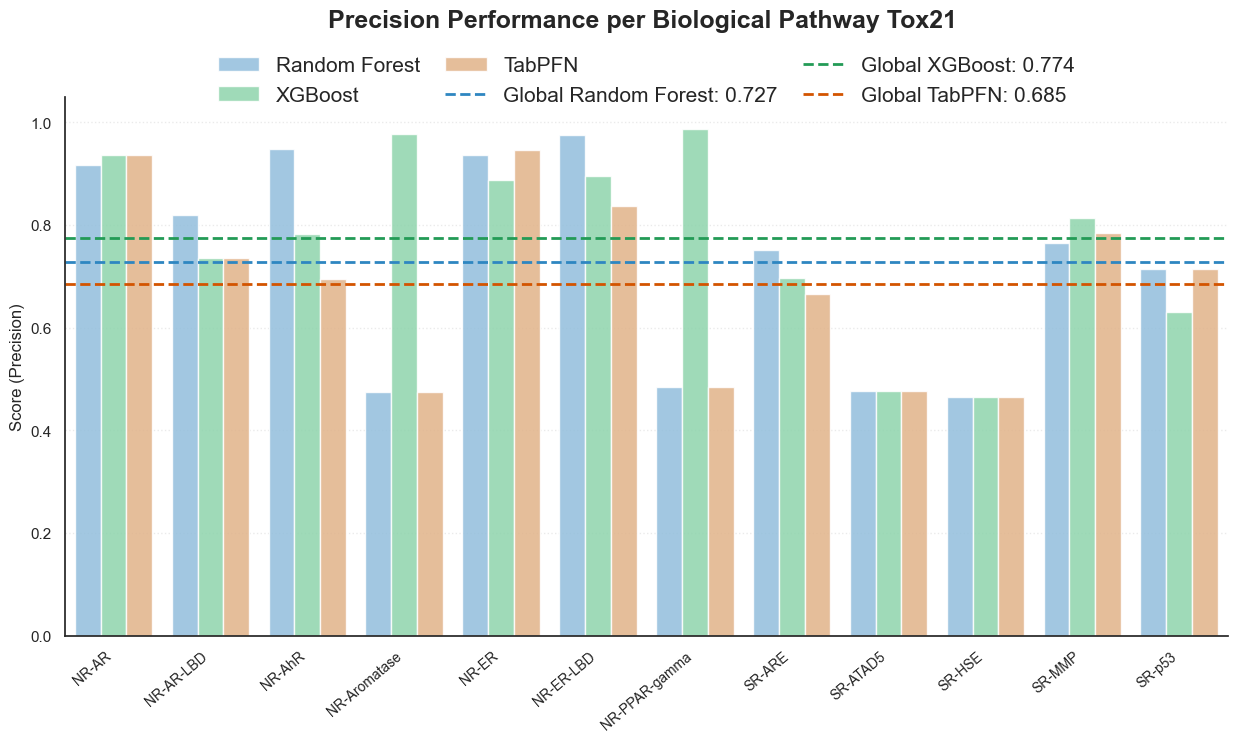

In [97]:
# ==========================================
# BLOCO 7: PERFORMANCE POR VIA (TOX21) - MÉDIAS GLOBAIS CORRETAS
# ==========================================

# 1. Configuração das Métricas e Dados
metrica_barra = 'Precision'   # O que vai nas barras individuais
metrica_linha = 'Precision_Global'  # O valor real ponderado do outro CSV
title_base = "Precision Performance per Biological Pathway Tox21 "

# 2. Definição das Paletas (Cores consistentes)
cores_barras = {
    'Random Forest': '#85C1E9', # Azul Claro
    'XGBoost': '#82E0AA',       # Verde Claro
    'TabPFN': '#F0B27A'         # Abóbora Claro
}

cores_linhas = {
    'Random Forest': '#2E86C1', # Azul Escuro
    'XGBoost': '#239B56',       # Verde Escuro
    'TabPFN': '#D35400'         # Abóbora Escuro
}

# 3. Plotagem
plt.figure(figsize=(15, 7))
sns.set_style("white")

# Plot das barras (Vias Individuais)
ax = sns.barplot(
    x='Via_Biologica',
    y=metrica_barra,
    hue='Modelo',
    data=df_tox_indiv,
    palette=cores_barras,
    edgecolor=None,
    alpha=0.85
)

# 4. Linhas de Performance Global (Buscando do df_tox_multi)
# Isso garante que a linha tracejada seja a média correta do modelo
for modelo in df_tox_indiv['Modelo'].unique():
    # Buscamos o valor exato no dataframe de relatório global
    valor_global = df_tox_multi[df_tox_multi['Modelo'] == modelo][metrica_linha].values[0]
    cor_escura = cores_linhas.get(modelo, 'black')

    plt.axhline(
        valor_global,
        color=cor_escura,
        linestyle='--',
        linewidth=2.0,
        alpha=1.0,
        label=f'Global {modelo}: {valor_global:.3f}'
    )

# --- ESTILIZAÇÃO ACADÊMICA ---
sns.despine()
plt.title(f"{title_base}",
          fontsize=18, fontweight='bold', pad=50)

plt.ylabel(f"Score (Precision)", fontsize=12)
plt.xlabel("", fontsize=12)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.ylim(0, 1.05) # Ajustado para caber as legendas

# 5. Legenda Horizontal no Topo
plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, .95),
    ncol=3,
    frameon=False,
    fontsize=15,
    columnspacing=1.2
)

plt.grid(axis='y', linestyle=':', alpha=0.4)

# --- SALVAMENTO ---
nome_arquivo = f"{title_base.replace(' ', '_').lower()}.png"
caminho_final = os.path.join(pasta_imagens, nome_arquivo)

# bbox_inches='tight' garante que o título e a legenda não sejam cortados
plt.savefig(caminho_final, dpi=300, bbox_inches='tight')

print(f"-> Gráfico corrigido com média global salvo em: {caminho_final}")
plt.show()

-> Gráfico corrigido com média global salvo em: C:\TCC_ICM_USP/Imagens/sider_precision_performance_per_organ_system.png


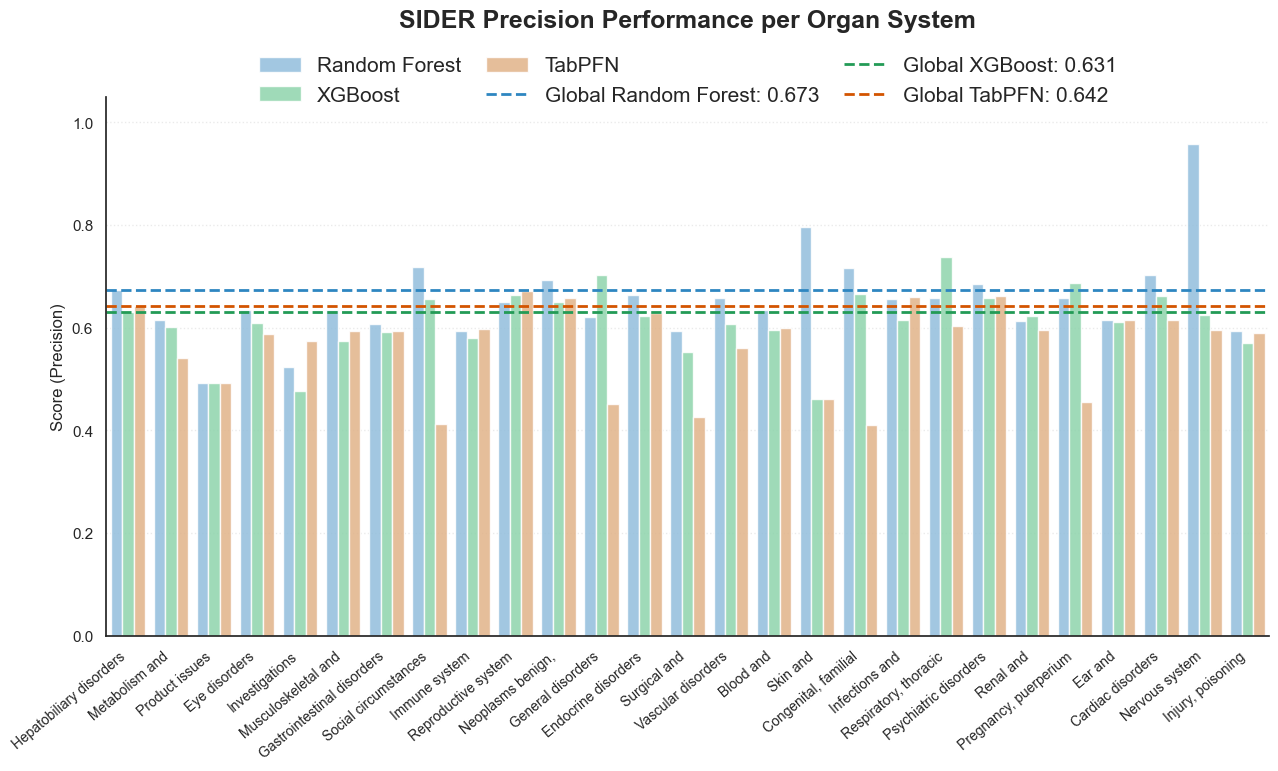

In [98]:
# ==========================================
# BLOCO 7: PERFORMANCE POR VIA (Sider) - MÉDIAS GLOBAIS CORRETAS
# ==========================================

# 1. Configuração das Métricas e Dados
metrica_barra = 'Precisao_Macro'   # O que vai nas barras individuais
metrica_linha = 'Precisao_Macro'  # O valor real ponderado do outro CSV
title_base = "SIDER Precision Performance per Organ System"

# 2. Definição das Paletas (Cores consistentes)
cores_barras = {
    'Random Forest': '#85C1E9', # Azul Claro
    'XGBoost': '#82E0AA',       # Verde Claro
    'TabPFN': '#F0B27A'         # Abóbora Claro
}

cores_linhas = {
    'Random Forest': '#2E86C1', # Azul Escuro
    'XGBoost': '#239B56',       # Verde Escuro
    'TabPFN': '#D35400'         # Abóbora Escuro
}

# 3. Plotagem
plt.figure(figsize=(15, 7))
sns.set_style("white")

df_temp = df_sider_indiv.copy()
df_temp['Sistema_Orgao_Curto'] = df_temp['Sistema_Orgao'].apply(lambda x: " ".join(x.split()[:2]))

# Plot das barras (Vias Individuais)
ax = sns.barplot(
    x='Sistema_Orgao_Curto',
    y=metrica_barra,
    hue='Modelo',
    data=df_temp,
    palette=cores_barras,
    edgecolor=None,
    alpha=0.85
)

# 4. Linhas de Performance Global (Buscando do df_sider_indiv)
# Isso garante que a linha tracejada seja a média correta do modelo
for modelo in df_sider_indiv['Modelo'].unique():
    # Buscamos o valor exato no dataframe de relatório global
    valor_global = df_sider_indiv[df_sider_indiv['Modelo'] == modelo][metrica_linha].values[0]
    cor_escura = cores_linhas.get(modelo, 'black')

    plt.axhline(
        valor_global,
        color=cor_escura,
        linestyle='--',
        linewidth=2.0,
        alpha=1.0,
        label=f'Global {modelo}: {valor_global:.3f}'
    )

# --- ESTILIZAÇÃO ACADÊMICA ---
sns.despine()
plt.title(f"{title_base}",
          fontsize=18, fontweight='bold', pad=50)

plt.ylabel(f"Score (Precision)", fontsize=12)
plt.xlabel("", fontsize=12)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.ylim(0, 1.05) # Ajustado para caber as legendas

# 5. Legenda Horizontal no Topo
plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, .95),
    ncol=3,
    frameon=False,
    fontsize=15,
    columnspacing=1.2
)

plt.grid(axis='y', linestyle=':', alpha=0.4)

# --- SALVAMENTO ---
nome_arquivo = f"{title_base.replace(' ', '_').lower()}.png"
caminho_final = os.path.join(pasta_imagens, nome_arquivo)

# bbox_inches='tight' garante que o título e a legenda não sejam cortados
plt.savefig(caminho_final, dpi=300, bbox_inches='tight')

print(f"-> Gráfico corrigido com média global salvo em: {caminho_final}")
plt.show()

-> Gráfico de F1-Micro salvo em: C:\TCC_ICM_USP/Imagens/f1-score_performance_per_pathway_tox21.png


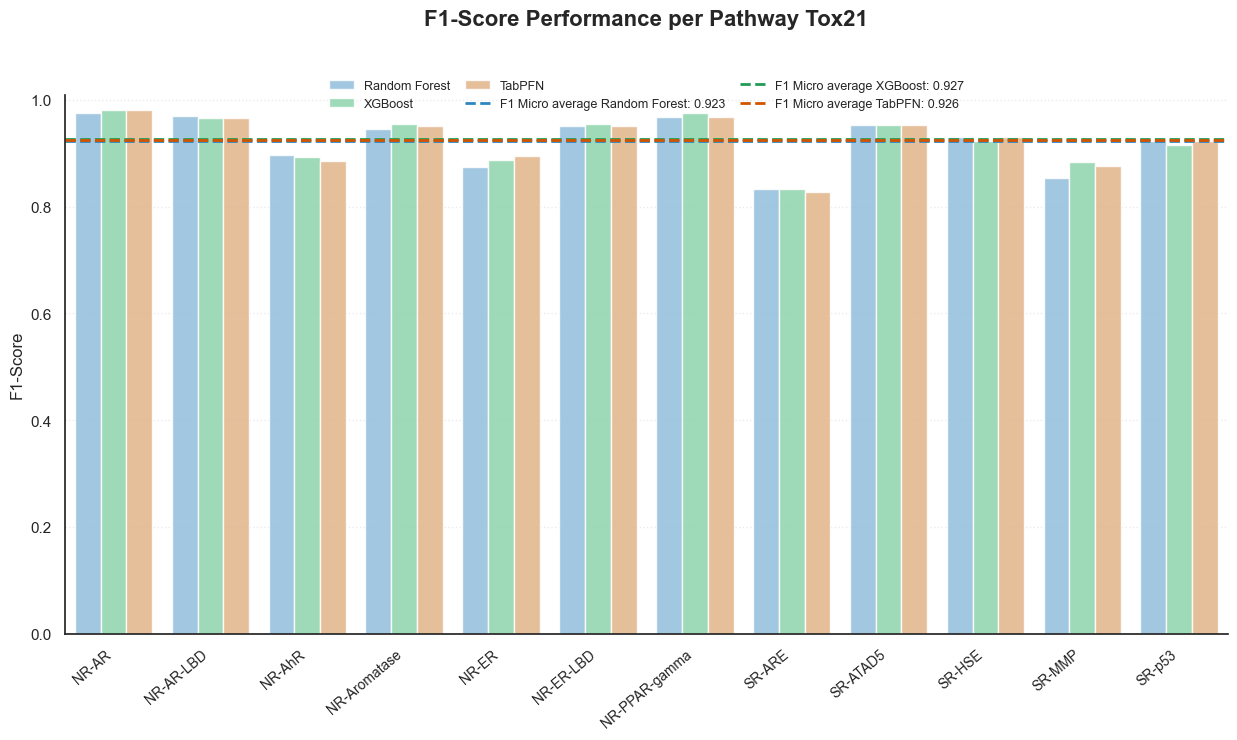

In [99]:
# ==========================================
# BLOCO 8: PERFORMANCE POR VIA (TOX21) - FOCO EM F1-MICRO
# ==========================================

# 1. Configuração das Métricas e Dados
metrica_barra = 'F1_Micro'        # F1 de cada via (do df_tox_indiv)
metrica_linha = 'F1_Micro_Global' # F1 Micro real (do df_tox_multi)
title_base = "F1-Score Performance per Pathway Tox21"

# 2. Definição das Paletas (Padrão do Projeto)
cores_barras = {'Random Forest': '#85C1E9', 'XGBoost': '#82E0AA', 'TabPFN': '#F0B27A'}
cores_linhas = {'Random Forest': '#2E86C1', 'XGBoost': '#239B56', 'TabPFN': '#D35400'}

# 3. Plotagem
plt.figure(figsize=(15, 7))
sns.set_style("white")

# Plot das barras (F1 Individual)
ax = sns.barplot(
    x='Via_Biologica',
    y=metrica_barra,
    hue='Modelo',
    data=df_tox_indiv,
    palette=cores_barras,
    edgecolor=None,
    alpha=0.85
)

# 4. Linhas de F1 Micro Global (Buscando do df_tox_multi)
for modelo in df_tox_indiv['Modelo'].unique():
    # Busca o F1 Micro Global no dataframe consolidado
    valor_f1_global = df_tox_multi[df_tox_multi['Modelo'] == modelo][metrica_linha].values[0]
    cor_escura = cores_linhas.get(modelo, 'black')

    plt.axhline(
        valor_f1_global,
        color=cor_escura,
        linestyle='--',
        linewidth=2.0,
        alpha=1.0,
        label=f'F1 Micro average {modelo}: {valor_f1_global:.3f}'
    )

# --- ESTILIZAÇÃO ACADÊMICA ---
sns.despine()
plt.title(f"{title_base}",
          fontsize=16, fontweight='bold', pad=50)

plt.ylabel(f"F1-Score", fontsize=12)
plt.xlabel("", fontsize=12)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.ylim(0, 1.01) # F1 costuma ser um pouco mais alto que PR-AUC

# 5. Legenda Horizontal no Topo
plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, .95),
    ncol=3,
    frameon=False,
    fontsize=9,
    columnspacing=1.2
)

plt.grid(axis='y', linestyle=':', alpha=0.4)

# --- SALVAMENTO ---
nome_arquivo = f"{title_base.replace(' ', '_').lower()}.png"
caminho_final = os.path.join(pasta_imagens, nome_arquivo)

# bbox_inches='tight' evita cortes na legenda larga
plt.savefig(caminho_final, dpi=300, bbox_inches='tight')

print(f"-> Gráfico de F1-Micro salvo em: {caminho_final}")
plt.show()

-> Gráfico corrigido com média global salvo em: C:\TCC_ICM_USP/Imagens/f1_micro_performance_per_organ_system_sider_.png


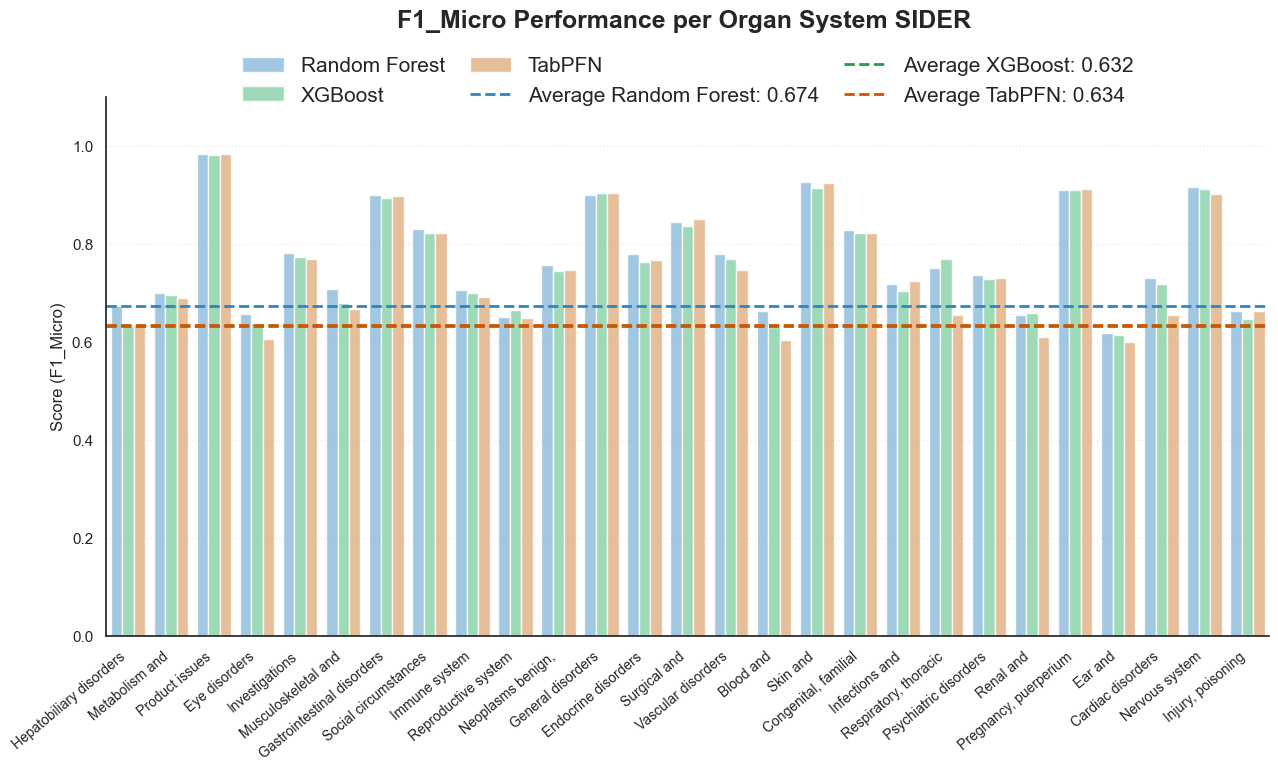

In [100]:
# ==========================================
# BLOCO 8,1: PERFORMANCE POR VIA (Sider) - MÉDIAS GLOBAIS CORRETAS
# ==========================================

# 1. Configuração das Métricas e Dados
metrica_barra = 'F1_Micro'   # O que vai nas barras individuais
metrica_linha = 'F1_Micro'  # O valor real ponderado do outro CSV
title_base = "F1_Micro Performance per Organ System SIDER "

# 2. Definição das Paletas (Cores consistentes)
cores_barras = {
    'Random Forest': '#85C1E9', # Azul Claro
    'XGBoost': '#82E0AA',       # Verde Claro
    'TabPFN': '#F0B27A'         # Abóbora Claro
}

cores_linhas = {
    'Random Forest': '#2E86C1', # Azul Escuro
    'XGBoost': '#239B56',       # Verde Escuro
    'TabPFN': '#D35400'         # Abóbora Escuro
}

# 3. Plotagem
plt.figure(figsize=(15, 7))
sns.set_style("white")

# --- ALTERAÇÃO SOLICITADA: Encurtamento das labels do eixo X ---
# Criamos uma versão temporária com nomes encurtados para o plot
df_temp = df_sider_indiv.copy()
df_temp['Sistema_Orgao_Curto'] = df_temp['Sistema_Orgao'].apply(lambda x: " ".join(x.split()[:2]))

# Plot das barras (Vias Individuais)
ax = sns.barplot(
    x='Sistema_Orgao_Curto',
    y=metrica_barra,
    hue='Modelo',
    data=df_temp,
    palette=cores_barras,
    edgecolor=None,
    alpha=0.85
)

# 4. Linhas de Performance Global (Buscando do df_sider_indiv)
# Isso garante que a linha tracejada seja a média correta do modelo
for modelo in df_sider_indiv['Modelo'].unique():
    # Buscamos o valor exato no dataframe de relatório global
    valor_global = df_sider_indiv[df_sider_indiv['Modelo'] == modelo][metrica_linha].values[0]
    cor_escura = cores_linhas.get(modelo, 'black')

    plt.axhline(
        valor_global,
        color=cor_escura,
        linestyle='--',
        linewidth=2.0,
        alpha=1.0,
        label=f'Average {modelo}: {valor_global:.3f}'
    )

# --- ESTILIZAÇÃO ACADÊMICA ---
sns.despine()
plt.title(f"{title_base}",
          fontsize=18, fontweight='bold', pad=50)

plt.ylabel(f"Score (F1_Micro)", fontsize=12)
plt.xlabel("", fontsize=12)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.ylim(0, 1.1) # Ajustado para caber as legendas

# 5. Legenda Horizontal no Topo
plt.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 0.95),
    ncol=3,
    frameon=False,
    fontsize=15,
    columnspacing=1.2
)

plt.grid(axis='y', linestyle=':', alpha=0.4)

# --- SALVAMENTO ---
nome_arquivo = f"{title_base.replace(' ', '_').lower()}.png"
caminho_final = os.path.join(pasta_imagens, nome_arquivo)

# bbox_inches='tight' garante que o título e a legenda não sejam cortados
plt.savefig(caminho_final, dpi=300, bbox_inches='tight')

print(f"-> Gráfico corrigido com média global salvo em: {caminho_final}")
plt.show()

-> Gráfico salvo com nomes personalizados em: C:\TCC_ICM_USP/Imagens/multi-label_performance_tox21.png


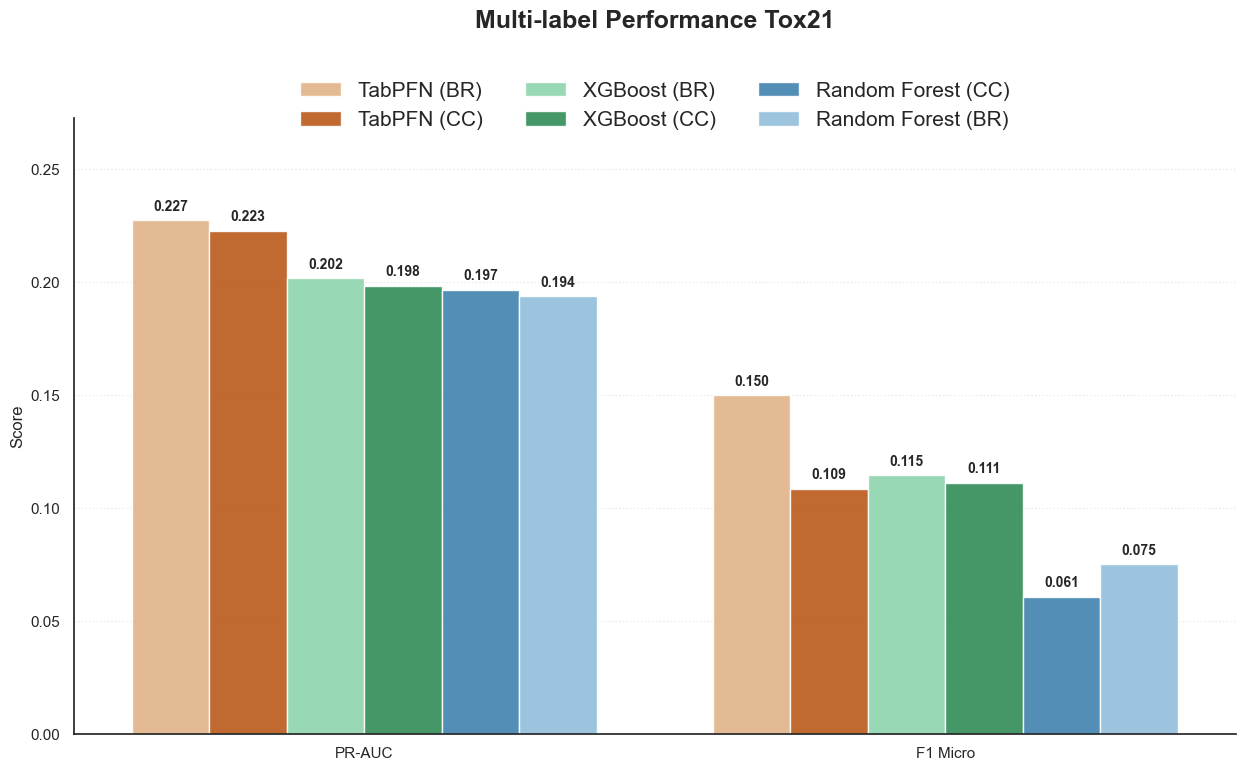

In [101]:
# ==========================================
# BLOCO 9: RESULTADOS TOX21 (ESTRATÉGIAS BR VS CC)
# ==========================================

# 1. Configuração das métricas (nomes originais do CSV)
metricas_originais = ['PR_AUC', 'F1_Macro (Label-based)']
title_tox = "Multi-label Performance Tox21"

# 2. Preparação dos dados
df_plot_tox_cohe = df_tox_cohesive.melt(
    id_vars=['Modelo'],
    value_vars=metricas_originais,
    var_name='Metrica',
    value_name='Valor'
)

# --- AJUSTE MANUAL DOS RÓTULOS ---
# Aqui você define como quer que o nome apareça no gráfico
mapeamento_nomes = {
    'PR_AUC': 'PR-AUC',
    'F1_Macro (Label-based)': 'F1 Micro'
}
df_plot_tox_cohe['Metrica'] = df_plot_tox_cohe['Metrica'].map(mapeamento_nomes)

# 3. Paleta de Cores Padronizada (Mesma do SIDER)
palette_padrao = {
    'Random Forest (BR)': '#85C1E9', 'Random Forest (CC)': '#2E86C1',
    'XGBoost (BR)': '#82E0AA',       'XGBoost (CC)': '#239B56',
    'TabPFN (BR)': '#F0B27A',        'TabPFN (CC)': '#D35400'
}

# 4. Plotagem
plt.figure(figsize=(15, 8))
sns.set_style("white")

ax = sns.barplot(
    x='Metrica', y='Valor', hue='Modelo',
    data=df_plot_tox_cohe, palette=palette_padrao,
    edgecolor=None, alpha=0.9
)

# Adicionando rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, fontsize=10, fontweight='bold')

# --- ESTILIZAÇÃO ---
sns.despine()
plt.title(title_tox, fontsize=18, fontweight='bold', pad=65)
plt.ylabel("Score", fontsize=12)
plt.xlabel("", fontsize=12)

# Ajuste do limite Y baseado no novo DataFrame mapeado
plt.ylim(0, df_plot_tox_cohe['Valor'].max() * 1.2) 

plt.legend(
    loc='lower center', bbox_to_anchor=(0.5, .95),
    ncol=3, frameon=False, fontsize=15
)
plt.grid(axis='y', linestyle=':', alpha=0.4)

# --- SALVAMENTO ---
nome_arq_tox = f"{title_tox.replace(' ', '_').replace(':', '').lower()}.png"
caminho_final = os.path.join(pasta_imagens, nome_arq_tox)
plt.savefig(caminho_final, dpi=300, bbox_inches='tight')


print(f"-> Gráfico salvo com nomes personalizados em: {caminho_final}")
plt.show()

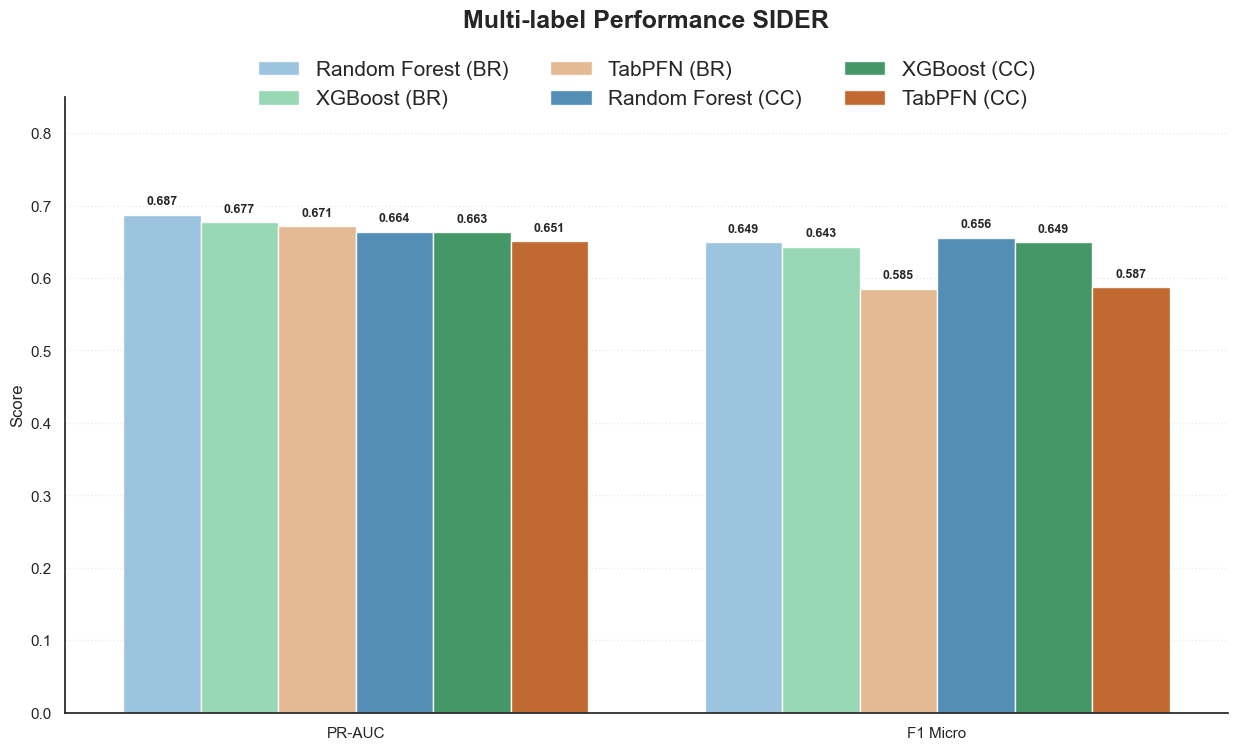

In [102]:
# ==========================================
# BLOCO 10: RESULTADOS SIDER (ESTRATÉGIAS BR VS CC)
# ==========================================

# 1. Configuração das métricas (SIDER costuma usar F1 Macro e PR_AUC)
metricas_sider = ['PR_AUC', 'F1_Macro (Label-based)']
title_sider = "Multi-label Performance SIDER"

# 2. Preparação dos dados
df_plot_sider = df_sider.melt(
    id_vars=['Modelo'],
    value_vars=metricas_originais,
    var_name='Metrica',
    value_name='Valor'
)

# --- AJUSTE MANUAL DOS RÓTULOS ---
# Aqui você define como quer que o nome apareça no gráfico
mapeamento_nomes = {
    'PR_AUC': 'PR-AUC',
    'F1_Macro (Label-based)': 'F1 Micro'
}
df_plot_sider['Metrica'] = df_plot_sider['Metrica'].map(mapeamento_nomes)


# 3. Plotagem (Usando a mesma paleta definida no bloco anterior)
plt.figure(figsize=(15, 8))
sns.set_style("white")

ax = sns.barplot(
    x='Metrica', y='Valor', hue='Modelo',
    data=df_plot_sider, palette=palette_padrao,
    edgecolor=None, alpha=0.9
)

# Adicionando rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=5, fontsize=9, fontweight='bold')

# --- ESTILIZAÇÃO ---
sns.despine()
plt.title(title_sider, fontsize=18, fontweight='bold', pad=50)
plt.ylabel("Score", fontsize=12)
plt.xlabel("", fontsize=12)
plt.ylim(0, 0.85)

plt.legend(
    loc='lower center', bbox_to_anchor=(0.5, .95),
    ncol=3, frameon=False, fontsize=15
)
plt.grid(axis='y', linestyle=':', alpha=0.4)

# --- SALVAMENTO ---
nome_arq_sider = f"{title_sider.replace(' ', '_').lower()}.png"
plt.savefig(os.path.join(pasta_imagens, nome_arq_sider), dpi=300, bbox_inches='tight')
plt.show()